In [1]:
# ============================================================
# AI Innovators Lab: Spam Detection
# Goal: Train an AI model that can classify a text message as
#       Spam or Not Spam.
#
# Example:
# Input: "Congratulations! You won $1000."
# Prediction: Spam
#
# Dataset:
# UCI SMS Spam Collection
# Link: https://archive.ics.uci.edu/dataset/228/sms+spam+collection
#
# This project is beginner-friendly because students can type
# their own messages and see how the AI classifies them.
# ============================================================

print("Welcome to the Spam Detection Project!")
print("Goal: Build an AI model that can detect spam text messages.")





Welcome to the Spam Detection Project!
Goal: Build an AI model that can detect spam text messages.


In [2]:
# ============================================================
# Step 1: Import required libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import requests
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries loaded successfully!")



Libraries loaded successfully!


In [3]:
# ============================================================
# Step 2: Download the SMS Spam Collection dataset
#
# The dataset is downloaded from the UCI Machine Learning Repository.
# It contains two labels:
# - ham  = normal message
# - spam = unwanted/spam message
# ============================================================

dataset_url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_file = "sms_spam_collection.zip"
extract_folder = "sms_spam_collection"

# Download dataset
response = requests.get(dataset_url)

with open(zip_file, "wb") as file:
    file.write(response.content)

print("Dataset downloaded successfully!")

# Extract zip file
if not os.path.exists(extract_folder):
    os.makedirs(extract_folder)

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("Dataset extracted successfully!")



Dataset downloaded successfully!
Dataset extracted successfully!


In [4]:
# ============================================================
# Step 3: Load the dataset into Python
#
# The file is named SMSSpamCollection.
# Each row has:
# - label: ham or spam
# - message: the text message
# ============================================================

file_path = os.path.join(extract_folder, "SMSSpamCollection")

data = pd.read_csv(
    file_path,
    sep="\t",
    header=None,
    names=["label", "message"]
)

print("Dataset loaded successfully!")
print("Number of messages:", len(data))
print(data.head())



Dataset loaded successfully!
Number of messages: 5572
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...



Number of messages by category:
label
ham     4825
spam     747
Name: count, dtype: int64


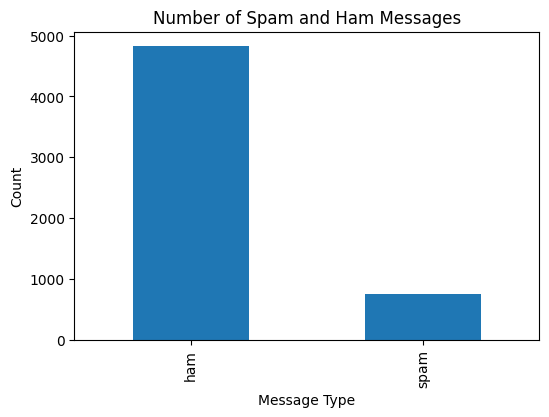

In [5]:
# ============================================================
# Step 4: Explore the dataset
# ============================================================

print("\nNumber of messages by category:")
print(data["label"].value_counts())

plt.figure(figsize=(6, 4))
data["label"].value_counts().plot(kind="bar")
plt.title("Number of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()



In [6]:
# ============================================================
# Step 5: Convert labels into numbers
#
# Machine learning models understand numbers better than words.
# We convert:
# ham  -> 0
# spam -> 1
# ============================================================

data["label_number"] = data["label"].map({
    "ham": 0,
    "spam": 1
})

print(data.head())



  label                                            message  label_number
0   ham  Go until jurong point, crazy.. Available only ...             0
1   ham                      Ok lar... Joking wif u oni...             0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...             1
3   ham  U dun say so early hor... U c already then say...             0
4   ham  Nah I don't think he goes to usf, he lives aro...             0


In [7]:
# ============================================================
# Step 6: Split the data into training and testing sets
#
# Training set: used to teach the AI
# Testing set: used to check how well the AI learned
# ============================================================

X = data["message"]
y = data["label_number"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))



Training messages: 4457
Testing messages: 1115


In [8]:
# ============================================================
# Step 7: Convert text into numbers
#
# A machine learning model cannot directly understand words.
# CountVectorizer turns text into word-count features.
#
# Example:
# "win money now" -> numbers showing how many times each word appears
# ============================================================

vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

print("Text converted into numbers successfully!")
print("Number of unique words learned:", len(vectorizer.get_feature_names_out()))



Text converted into numbers successfully!
Number of unique words learned: 7403


In [9]:
# ============================================================
# Step 8: Build and train the AI model
#
# We use Multinomial Naive Bayes.
# This is a classic model for text classification.
# It is fast, simple, and works well for spam detection.
# ============================================================

model = MultinomialNB()

model.fit(X_train_vectorized, y_train)

print("Model training completed!")



Model training completed!


In [10]:
# ============================================================
# Step 9: Evaluate the model
#
# Accuracy tells us how often the model is correct.
# ============================================================

y_pred = model.predict(X_test_vectorized)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Model Accuracy: 98.48 %

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115


Confusion Matrix:
[[961   5]
 [ 12 137]]


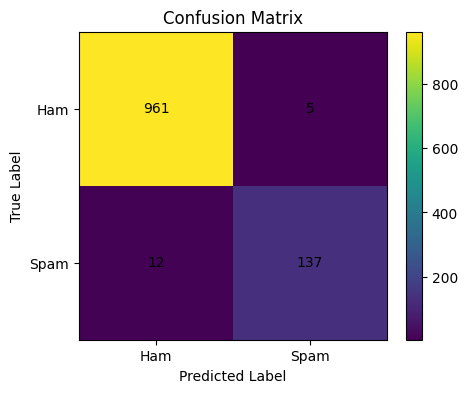

In [11]:
# ============================================================
# Step 10: Visualize the confusion matrix
#
# Confusion Matrix meaning:
# Top-left: Ham correctly predicted as Ham
# Top-right: Ham incorrectly predicted as Spam
# Bottom-left: Spam incorrectly predicted as Ham
# Bottom-right: Spam correctly predicted as Spam
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["Ham", "Spam"])
plt.yticks([0, 1], ["Ham", "Spam"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()



In [12]:
# ============================================================
# Step 11: Test the model with custom messages
#
# Students can change these messages or add their own.
# ============================================================

custom_messages = [
    "Congratulations! You won $1000. Click here to claim your prize.",
    "Hey, are we still meeting at 5 PM today?",
    "URGENT! Your account has been selected for a free reward.",
    "Can you send me the homework file?",
    "You have won a brand new phone. Reply WIN now."
]

custom_messages_vectorized = vectorizer.transform(custom_messages)
custom_predictions = model.predict(custom_messages_vectorized)
custom_probabilities = model.predict_proba(custom_messages_vectorized)

print("Custom Message Predictions:\n")

for message, prediction, probability in zip(custom_messages, custom_predictions, custom_probabilities):
    label = "SPAM" if prediction == 1 else "HAM / NOT SPAM"
    confidence = max(probability) * 100

    print("Message:", message)
    print("Prediction:", label)
    print("Confidence:", round(confidence, 2), "%")
    print("-" * 60)



Custom Message Predictions:

Message: Congratulations! You won $1000. Click here to claim your prize.
Prediction: SPAM
Confidence: 100.0 %
------------------------------------------------------------
Message: Hey, are we still meeting at 5 PM today?
Prediction: HAM / NOT SPAM
Confidence: 99.95 %
------------------------------------------------------------
Message: URGENT! Your account has been selected for a free reward.
Prediction: SPAM
Confidence: 99.99 %
------------------------------------------------------------
Message: Can you send me the homework file?
Prediction: HAM / NOT SPAM
Confidence: 91.54 %
------------------------------------------------------------
Message: You have won a brand new phone. Reply WIN now.
Prediction: SPAM
Confidence: 99.77 %
------------------------------------------------------------


In [13]:
# ============================================================
# Step 12: Let students type their own message
#
# Type a text message and the AI will predict if it is spam.
# ============================================================

student_message = input("Type a message to test: ")

student_message_vectorized = vectorizer.transform([student_message])
student_prediction = model.predict(student_message_vectorized)[0]
student_probability = model.predict_proba(student_message_vectorized)[0]

if student_prediction == 1:
    print("\nThe AI predicts: SPAM")
else:
    print("\nThe AI predicts: HAM / NOT SPAM")

print("Confidence:", round(max(student_probability) * 100, 2), "%")



Type a message to test: Hello, win 10k

The AI predicts: SPAM
Confidence: 75.5 %


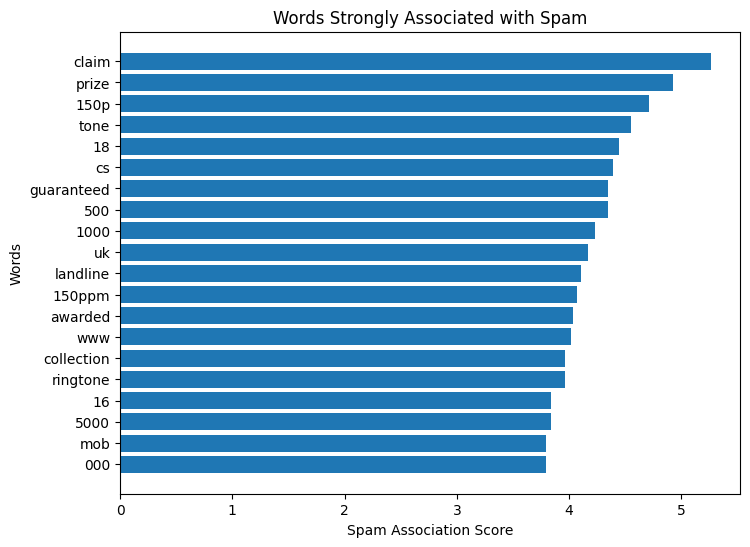

Top words associated with spam:
- claim
- prize
- 150p
- tone
- 18
- cs
- guaranteed
- 500
- 1000
- uk
- landline
- 150ppm
- awarded
- www
- collection
- ringtone
- 16
- 5000
- mob
- 000


In [14]:
# ============================================================
# Step 13: Show important spam-related words
#
# This helps students understand what words may influence
# the model's spam decision.
# ============================================================

feature_names = np.array(vectorizer.get_feature_names_out())

# Naive Bayes stores log probabilities for each class.
# Class 0 = ham, Class 1 = spam
spam_word_scores = model.feature_log_prob_[1]
ham_word_scores = model.feature_log_prob_[0]

# Words more associated with spam
spam_indicator_scores = spam_word_scores - ham_word_scores

top_spam_indices = np.argsort(spam_indicator_scores)[-20:]

top_spam_words = feature_names[top_spam_indices]
top_spam_scores = spam_indicator_scores[top_spam_indices]

plt.figure(figsize=(8, 6))
plt.barh(top_spam_words, top_spam_scores)
plt.title("Words Strongly Associated with Spam")
plt.xlabel("Spam Association Score")
plt.ylabel("Words")
plt.show()

print("Top words associated with spam:")
for word in top_spam_words[::-1]:
    print("-", word)



In [15]:
# ============================================================
# Step 14: Save the model and vectorizer
#
# The model alone is not enough for text.
# We also need to save the vectorizer that converts text into numbers.
# ============================================================

import pickle

with open("spam_detection_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("text_vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

print("Model saved as spam_detection_model.pkl")
print("Vectorizer saved as text_vectorizer.pkl")



Model saved as spam_detection_model.pkl
Vectorizer saved as text_vectorizer.pkl


In [16]:
# ============================================================
# Step 15: Reflection questions for final showcase
# ============================================================

reflection_questions = [
    "1. What problem does your AI model solve?",
    "2. What dataset did you use?",
    "3. What is the difference between spam and ham?",
    "4. How did the AI convert text into numbers?",
    "5. What was your model accuracy?",
    "6. What types of words appeared important for spam detection?",
    "7. Did the model make any mistakes?",
    "8. How could this type of AI be used in real life?",
    "9. What are the risks of using AI for message filtering?"
]

print("\nReflection Questions:")
for question in reflection_questions:
    print(question)


Reflection Questions:
1. What problem does your AI model solve?
2. What dataset did you use?
3. What is the difference between spam and ham?
4. How did the AI convert text into numbers?
5. What was your model accuracy?
6. What types of words appeared important for spam detection?
7. Did the model make any mistakes?
8. How could this type of AI be used in real life?
9. What are the risks of using AI for message filtering?


# ============================================================
# Presentation Template for Students
# ============================================================

presentation_template = """
Project Title:
Spam Detection AI Model

Team Members:
[Names]

Problem:
We wanted to build an AI model that can identify whether a text message is spam or not spam.

Dataset:
We used the UCI SMS Spam Collection dataset.
Dataset Link:
https://archive.ics.uci.edu/dataset/228/sms+spam+collection

How It Works:
The model learns from labeled text messages. It looks at words and patterns that often appear in spam messages.

Model Used:
Multinomial Naive Bayes

Result:
Our model reached approximately ____% accuracy.

Demo:
We typed a new message, and the model predicted whether it was spam or not spam.

What We Learned:
We learned how AI can classify text messages using data.

Future Improvement:
We could train with more recent spam examples, use better text features, or test messages from different languages.
"""

print(presentation_template)